# Oilgas vendor performance analysis

In [25]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

oilgas = pd.read_csv("oilgas_vendor_performance.csv")

In [11]:
oilgas["Overall_Performance_Score"] = (oilgas["On_Time_Delivery_Pct"] + oilgas["Safety_Compliance_Pct"])/2

oilgas.columns

Index(['PO_Number', 'Date', 'Vendor_Name', 'Category', 'Region',
       'Contract_Type', 'Contract_Value', 'On_Time_Delivery_Pct',
       'Quality_Score', 'Safety_Compliance_Pct', 'Response_Time_Hours',
       'Defect_Rate_Pct', 'Cost_Variance_Pct', 'Overall_Performance_Score'],
      dtype='object')

In [12]:
oilgas

,PO_Number,Date,Vendor_Name,Category,Region,Contract_Type,Contract_Value,On_Time_Delivery_Pct,Quality_Score,Safety_Compliance_Pct,Response_Time_Hours,Defect_Rate_Pct,Cost_Variance_Pct,Overall_Performance_Score
Vendor_Code,,,,,,,,,,,,,,
V1467,PO000001,2023-01-01,OceanFreight Services,Logistics & Transportation,Gulf Coast,Fixed Price,385960.49,87.6,9.0,97.8,9.1,1.07,-6.92,92.70
V1428,PO000002,2023-01-02,ProTech Safety,Safety & PPE,North Sea,Spot Purchase,113688.78,85.0,6.1,98.4,63.5,2.72,17.01,91.70
V1311,PO000003,2023-01-07,DeepCore Industries,Drilling Equipment,Asia Pacific,Spot Purchase,543394.56,89.6,8.9,89.2,46.1,3.42,-3.96,89.40
V1103,PO000004,2023-01-09,SafeGuard Supply Co,Safety & PPE,West Africa,Fixed Price,173076.33,81.7,9.7,99.0,12.4,1.18,16.79,90.35
V1112,PO000005,2023-01-11,PetroMaintenance Corp,Maintenance & Repair,Asia Pacific,Spot Purchase,146569.09,86.6,9.1,94.1,7.3,1.78,14.43,90.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
V1110,PO000216,2024-12-02,Equipment Care Plus,Maintenance & Repair,Gulf Coast,Framework Agreement,99203.57,92.9,9.2,99.3,17.3,0.27,4.61,96.10
V1467,PO000217,2024-12-11,OceanFreight Services,Logistics & Transportation,North Sea,Fixed Price,132262.94,86.7,8.4,87.9,26.0,3.71,-13.55,87.30
V1291,PO000218,2024-12-19,Advanced Fluids Ltd,Chemical Supplies,Asia Pacific,Spot Purchase,446713.93,80.4,7.2,81.4,46.2,3.50,-3.51,80.90


In [13]:
print(oilgas[["On_Time_Delivery_Pct", "Safety_Compliance_Pct", "Overall_Performance_Score"]].head())

             On_Time_Delivery_Pct  Safety_Compliance_Pct  \
Vendor_Code                                                
V1467                        87.6                   97.8   
V1428                        85.0                   98.4   
V1311                        89.6                   89.2   
V1103                        81.7                   99.0   
V1112                        86.6                   94.1   

             Overall_Performance_Score  
Vendor_Code                             
V1467                            92.70  
V1428                            91.70  
V1311                            89.40  
V1103                            90.35  
V1112                            90.35  


In [14]:
pivot1 = oilgas.groupby("Category").agg({"Contract_Value":"sum", "Quality_Score":"mean", "On_Time_Delivery_Pct":"mean" })
pivot1 = pivot1.sort_values(by= "Contract_Value", ascending = False)
print(pivot1)

                            Contract_Value  Quality_Score  \
Category                                                    
Drilling Equipment             24421210.25       8.003333   
Engineering Services           16556520.68       8.154054   
Chemical Supplies              13962144.54       7.795455   
Maintenance & Repair            7914148.81       8.031707   
Logistics & Transportation      6618860.10       7.857143   
Safety & PPE                    4198750.84       8.155172   

                            On_Time_Delivery_Pct  
Category                                          
Drilling Equipment                     84.909677  
Engineering Services                   87.164103  
Chemical Supplies                      84.200000  
Maintenance & Repair                   84.202326  
Logistics & Transportation             85.828571  
Safety & PPE                           84.057576  


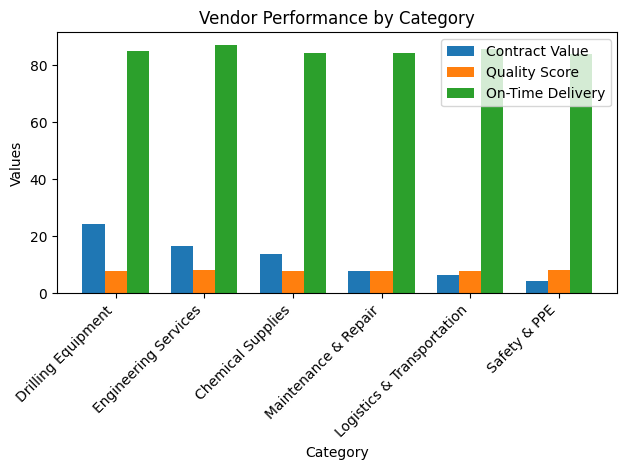

In [37]:
x = np.arange(len(pivot1.index))
width = 0.25

plt.bar(x - width, pivot1["Contract_Value"]/1000000, 
        width, label="Contract Value")
plt.bar(x, pivot1["Quality_Score"],
        width, label="Quality Score")
plt.bar(x + width, pivot1["On_Time_Delivery_Pct"],
        width, label="On-Time Delivery")

plt.xticks(x, pivot1.index, rotation=45, ha="right")

plt.title("Vendor Performance by Category")
plt.xlabel("Category")
plt.ylabel("Values")

plt.legend()
plt.tight_layout()

plt.show()

In [39]:
pivot2 = oilgas.groupby("Region").agg({"On_Time_Delivery_Pct": "mean", "Safety_Compliance_Pct": "mean", "Quality_Score": "mean"})
print(pivot2)

              On_Time_Delivery_Pct  Safety_Compliance_Pct  Quality_Score
Region                                                                  
Asia Pacific             86.225000              91.872727       8.021429
Gulf Coast               86.857143              89.375510       7.910638
Middle East              82.326829              90.036585       8.157500
North Sea                88.382857              91.437143       7.663636
West Africa              82.037255              90.756863       8.142553


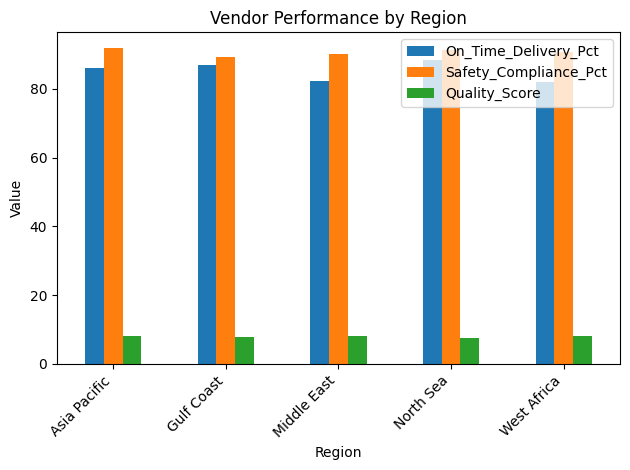

In [40]:
pivot2.plot(kind="bar",)
plt.title("Vendor Performance by Region")
plt.xlabel("Region")
plt.ylabel("Value")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [16]:
oilgas = pd.read_csv("oilgas_vendor_performance.csv", index_col = "Vendor_Code") 
oilgas 
pivot3 = oilgas.groupby("Contract_Type").agg({"Cost_Variance_Pct": "mean", "Quality_Score":"mean", "PO_Number": "count"})
print(pivot3)

                     Cost_Variance_Pct  Quality_Score  PO_Number
Contract_Type                                                   
Fixed Price                   4.031346       8.201852         57
Framework Agreement          -3.088980       7.587234         52
Spot Purchase                 2.545667       8.073770         62
Time & Material               2.031458       8.055319         49


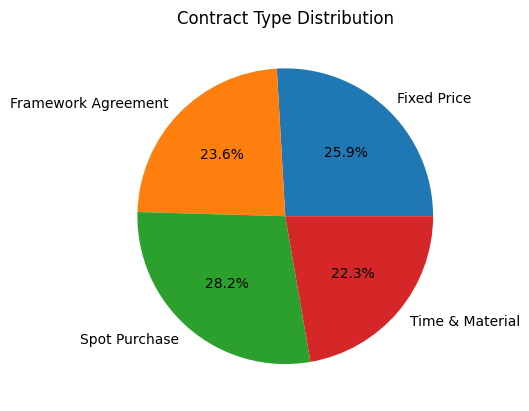

In [41]:
plt.figure()
plt.pie(pivot3["PO_Number"], labels=pivot3.index, autopct="%1.1f%%")
plt.title("Contract Type Distribution")
plt.show()

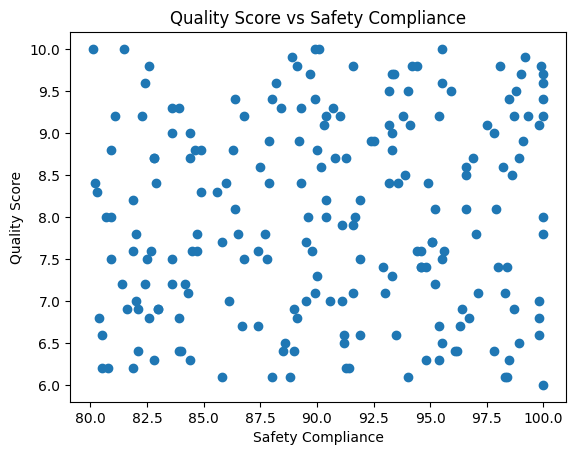

In [42]:
x = oilgas["Safety_Compliance_Pct"]
y = oilgas["Quality_Score"]

plt.scatter(x, y)
plt.xlabel("Safety Compliance")
plt.ylabel("Quality Score")
plt.title("Quality Score vs Safety Compliance")

plt.show()

In [19]:
oilgas["Overall_Performance_Score"] = (oilgas["On_Time_Delivery_Pct"] + oilgas["Safety_Compliance_Pct"])/2

oilgas.columns

Index(['PO_Number', 'Date', 'Vendor_Name', 'Category', 'Region',
       'Contract_Type', 'Contract_Value', 'On_Time_Delivery_Pct',
       'Quality_Score', 'Safety_Compliance_Pct', 'Response_Time_Hours',
       'Defect_Rate_Pct', 'Cost_Variance_Pct', 'Overall_Performance_Score'],
      dtype='object')

In [20]:
pivot4 = oilgas.groupby("Vendor_Name").agg({"Overall_Performance_Score": "mean"})

In [21]:
pivot4.head(5)

,Overall_Performance_Score
Vendor_Name,
Advanced Fluids Ltd,86.615909
ChemCore Industries,88.650000
Continental Carriers,85.904545
DeepCore Industries,87.515000
DrillTech Solutions,88.138462


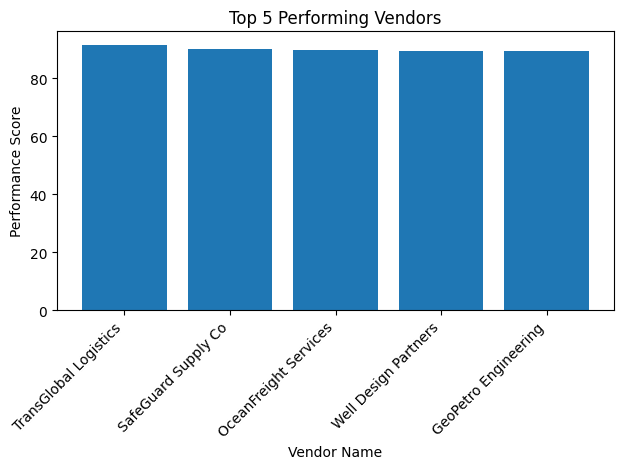

In [43]:
plt.bar(top5.index, top5["Overall_Performance_Score"])

plt.title("Top 5 Performing Vendors")
plt.xlabel("Vendor Name")
plt.ylabel("Performance Score")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [22]:
pivot4.tail(5)

,Overall_Performance_Score
Vendor_Name,
ProTech Safety,88.433333
Reservoir Solutions Inc,87.445833
SafeGuard Supply Co,90.100000
TransGlobal Logistics,91.621429
Well Design Partners,89.578571


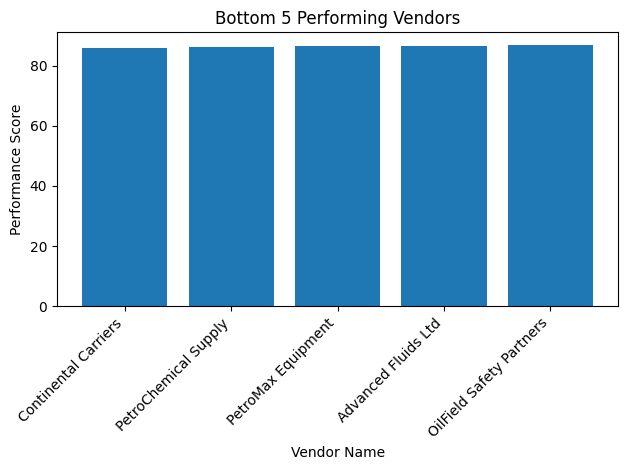

In [44]:
plt.bar(bottom5.index, bottom5["Overall_Performance_Score"])

plt.title("Bottom 5 Performing Vendors")
plt.xlabel("Vendor Name")
plt.ylabel("Performance Score")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [23]:
pivot5 = oilgas.groupby("Category").agg({"Defect_Rate_Pct":"mean"})
pivot5 = pivot5.sort_values(by = "Defect_Rate_Pct", ascending = False)
print(pivot5)

                            Defect_Rate_Pct
Category                                   
Engineering Services               3.337368
Drilling Equipment                 3.310323
Logistics & Transportation         3.304286
Safety & PPE                       3.137576
Chemical Supplies                  3.099545
Maintenance & Repair               2.851707


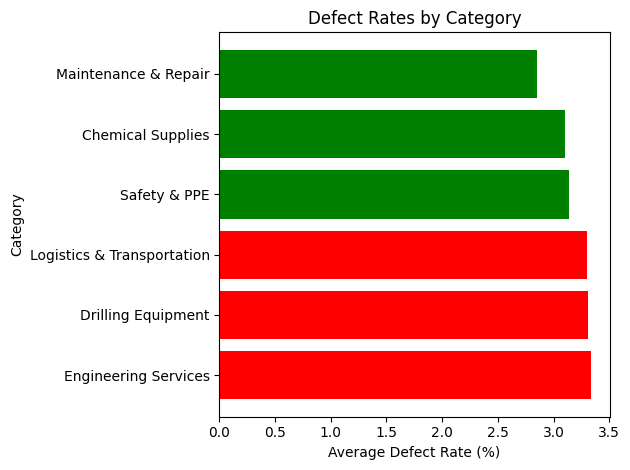

In [45]:
colors = []

for value in pivot5["Defect_Rate_Pct"]:
    if value > 3.2:
        colors.append("red")
    else:
        colors.append("green")
        
plt.barh(pivot5.index, pivot5["Defect_Rate_Pct"], color=colors)

plt.title("Defect Rates by Category")
plt.xlabel("Average Defect Rate (%)")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

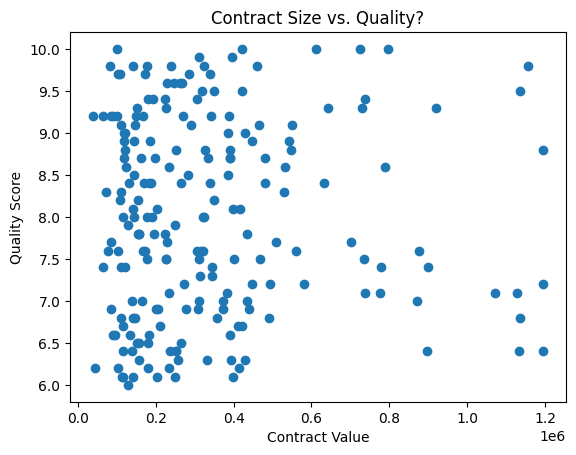

In [46]:
x = oilgas["Contract_Value"]
y = oilgas["Quality_Score"]

plt.scatter(x, y)

plt.title("Contract Size vs. Quality?")
plt.xlabel("Contract Value")
plt.ylabel("Quality Score")

plt.show()